In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from scipy.stats import distributions

In [2]:
FIG_SAVE_FMT = "png"

In [3]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2025-07-26_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-09-15_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2024_rotated_filtered_streamwise_v5.2.nc"
OPTAA_PATH = DATA_DIR / "CE01ISSM/ce01issm_optaa_processed.nc"
FLORT_PATH = DATA_DIR / "CE01ISSM/ce01issm_flort_processed.nc"

In [4]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)
optaa = xr.open_dataset(OPTAA_PATH)
flort = xr.open_dataset(FLORT_PATH)

# align optaa and flort datasets and average estimated chlorophyll
flort = flort.drop_dims("stats")
optaa_al, flort_al = xr.align(optaa.drop_duplicates("time"), flort.drop_duplicates("time"))

inner_shelf_chlorophyll = xr.Dataset(
    {
        "estimated_chlorophyll_flort": flort_al["estimated_chlorophyll"],
        "estimated_chlorophyll_optaa": optaa_al["estimated_chlorophyll"],
    },
)
inner_shelf_chlorophyll["estimated_chlorophyll"] = inner_shelf_chlorophyll.to_array(dim="new").mean(dim="new")
inner_shelf_chlorophyll = inner_shelf_chlorophyll.resample(time="1D").mean()

In [6]:
def lagged_correlation(
    a: xr.DataArray,
    b: xr.DataArray,
    lags: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Positive lags for b leading a, negative lags for a leading b.

    Args:
        a (xr.DataArray): time series
        b (xr.DataArray): time series
        lags (NDArray): lags to calculate cross correlation

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: tuple of correlation, conf. intervals, and data points for each lag

    """
    corr = np.full(lags.size, np.nan)
    confint = np.full((lags.size, 2), np.nan)
    n = np.full(lags.size, np.nan)
    for i, t in enumerate(lags):
        b_shift = b.shift(time=t)
        a_shift, b_shift = xr.align(a, b_shift)
        mask = ~np.isnan(a_shift) & ~np.isnan(b_shift)
        ccf = sm.tsa.ccf(
            a_shift[mask],
            b_shift[mask],
            adjusted=True,
            nlags=1,
            alpha=0.05,
        )
        corr[i] = ccf[0][0]
        confint[i] = ccf[1]
        n[i] = np.sum(mask)
    return corr, confint, n


def plot_correlations(
    lags: np.ndarray,
    corr: np.ndarray,
    confint: np.ndarray,
    n: np.ndarray,
    xlabel: str | None = None,
    ylabel: str | None = None,
) -> None:
    """Plot the correlations with confidence intervals. Designed for use with `lagged_correlation()`.

    Args:
        lags (NDArray): lags used for correlation
        corr (NDArray): correlation values
        confint (NDArray): confidence intervals for the correlations
        n (NDArray): number of data points used for each lag
        xlabel (str | None, optional): label for x-axis. Defaults to None.
        ylabel (str | None, optional): label for y-axis. Defaults to None.

    """
    n_eff = float(np.nanmean(n)) / 11
    alpha = 0.05
    rho_crit = float(
        np.sqrt(
            distributions.f.isf(alpha, 1, n_eff - 2) / (n_eff - 2 + distributions.f.isf(alpha, 1, n_eff - 2)),
        ),
    )

    _fig, ax = plt.subplots()
    ax.plot(lags, corr, color="k", lw=2)
    ax.fill_between(
        lags,
        confint[:, 0],
        confint[:, 1],
        color="gray",
        alpha=0.5,
        label="95% CI",
    )
    ax.axhline(rho_crit, color="k", ls="--", lw=1)
    ax.axhline(-rho_crit, color="k", ls="--", lw=1)
    ax.set_xlabel(xlabel) if xlabel else None
    ax.set_ylabel(ylabel) if ylabel else None
    ax.legend()
    plt.show()

In [7]:
# determine correlation between wind and velocity at each depth

lags = np.arange(-30, 31)
max_corr = np.full(velocity["depth"].size, np.nan)
for i, d in enumerate(velocity["depth"]):
    corr, confint, n = lagged_correlation(
        wind["coare_y"],
        velocity["u_proj"].sel(depth=d),
        lags,
    )
    max_corr[i] = corr[np.argmax(np.abs(corr))]

c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1179: RuntimeWarning: invalid value encountered in divide
  ret = cvf / (np.std(x) * np.std(y))
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1179: RuntimeWarning: invalid value encountered in divide
  ret = cvf / (np.std(x) * np.std(y))
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1179: RuntimeWarning: invalid value encountered in divide
  ret = cvf / (np.std(x) * np.std(y))
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1179: RuntimeWarning: invalid value encountered in divide
  ret = cvf / (np.std(x) * np.std(y))
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1179: RuntimeWar

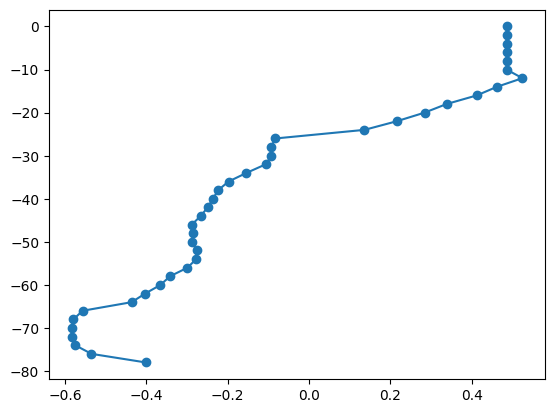

In [8]:
plt.plot(max_corr, -velocity["depth"].astype(float), marker="o")

In [9]:
# determine correlation between wind and inner shelf nitrate concentration

lags = np.arange(-30, 31)
corr, confint, n = lagged_correlation(
    wind["coare_y"],
    inner_nitrate["nitrate"].mean("depth"),
    lags,
)
corr[np.argmax(np.abs(corr))]

np.float64(-0.5070419407851)

In [10]:
# determine correlation between wind and inner shelf nitrate concentration

lags = np.arange(-30, 31)
corr, confint, n = lagged_correlation(
    wind["coare_y"],
    midshelf_nitrate["nitrate"].mean("depth"),
    lags,
)
corr[np.argmax(np.abs(corr))]

np.float64(-0.43789342239465334)

In [11]:
# determine correlation between wind and chloropohyll

lags = np.arange(-30, 31)
corr, confint, n = lagged_correlation(
    wind["coare_y"],
    inner_shelf_chlorophyll["estimated_chlorophyll"],
    lags,
)
corr[np.argmax(np.abs(corr))]

np.float64(-0.25075237801633204)

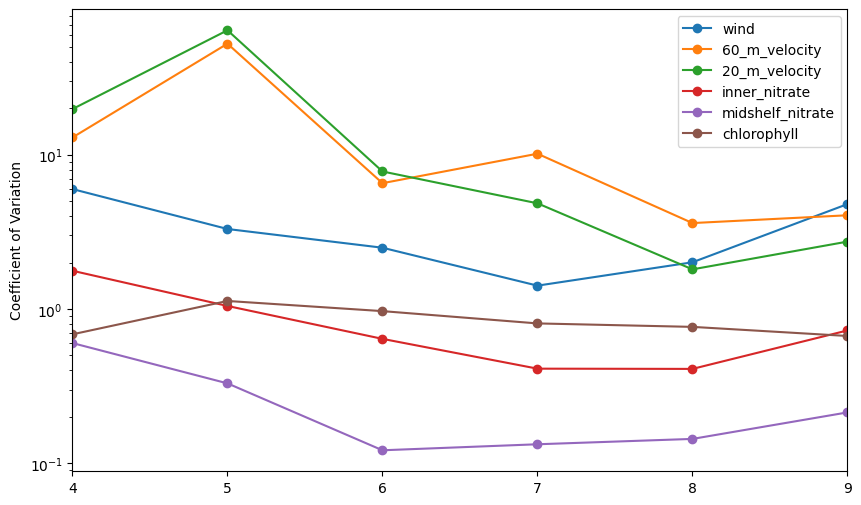

In [14]:
# monthly variance in wind stress, velocity, nitrate, and chlorophyll

monthly_variance = {
    "wind": wind["coare_y"].groupby("time.month").std("time"),
    "60_m_velocity": velocity["u_proj"].groupby("time.month").std("time").sel(depth=60),
    # "40_m_velocity": velocity["u_proj"].groupby("time.month").std("time").sel(depth=40),
    "20_m_velocity": velocity["u_proj"].groupby("time.month").std("time").sel(depth=20),
    "inner_nitrate": inner_nitrate["nitrate"].groupby("time.month").std("time").mean("depth"),
    "midshelf_nitrate": midshelf_nitrate["nitrate"].groupby("time.month").std("time").mean("depth"),
    "chlorophyll": inner_shelf_chlorophyll["estimated_chlorophyll"].groupby("time.month").std("time"),
}

monthly_means = {
    "wind": wind["coare_y"].groupby("time.month").mean("time"),
    "60_m_velocity": velocity["u_proj"].groupby("time.month").mean("time").sel(depth=60),
    # "40_m_velocity": velocity["u_proj"].groupby("time.month").mean("time").sel(depth=40),
    "20_m_velocity": velocity["u_proj"].groupby("time.month").mean("time").sel(depth=20),
    "inner_nitrate": inner_nitrate["nitrate"].groupby("time.month").mean("time").mean("depth"),
    "midshelf_nitrate": midshelf_nitrate["nitrate"].groupby("time.month").mean("time").mean("depth"),
    "chlorophyll": inner_shelf_chlorophyll["estimated_chlorophyll"].groupby("time.month").mean("time"),
}

plt.figure(figsize=(10, 6))

for var, mean in zip(monthly_variance.items(), monthly_means.items(), strict=True):
    plt.plot(
        var[1]["month"],
        var[1] / np.abs(mean[1]),
        marker="o",
        label=f"{var[0]}",
    )
plt.ylabel("Coefficient of Variation")
plt.legend()
plt.yscale("log")
# plt.ylim(0, 1)
plt.xlim(4, 9)
plt.axhline(0, color="k", ls="--", lw=1)